You might need to bootstrap the virtual environment from the console panel:
```bash
source .venv/bin/activate  # Activate if not already
```

Install required packages

In [1]:
pip install inference-sdk matplotlib pillow

Note: you may need to restart the kernel to use updated packages.


Imports

In [2]:
from inference_sdk import InferenceHTTPClient
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches

Matplotlib is building the font cache; this may take a moment.


Client

In [7]:
import os

# Load API key from environment variable
api_key = os.getenv('ROBOFLOW_PRIVATE_API_KEY')

if api_key is None:
    print("Warning: ROBOFLOW_PRIVATE_API_KEY not found in environment variables")
else:
    print("API key loaded successfully!")

# Fix certificate issue
import certifi
os.environ['REQUESTS_CA_BUNDLE'] = certifi.where()

# Initialize the Roboflow client
CLIENT = InferenceHTTPClient(
    api_url="https://serverless.roboflow.com",
    api_key=api_key
)

API key loaded successfully!


Inference

In [8]:
# Run the model on your image
# Note: You may need to find the exact model_id for the finetune-mrcnn model
# Format is usually "workspace/project/version"
result = CLIENT.infer("IMG_4014.jpeg", model_id="finetune-mrcnn/2")
print(result)

{'inference_id': 'd19a0b1b-5d1b-4710-ab7a-0dc83b1afb13', 'time': 0.43612215100074536, 'image': {'width': 4032, 'height': 3024}, 'predictions': [{'x': 958.5, 'y': 1721.5, 'width': 387.0, 'height': 1549.0, 'confidence': 0.934273898601532, 'class': 'book', 'class_id': 0, 'detection_id': 'da21637c-cdff-4bd5-92db-7cf38d9955ae', 'points': [{'x': 781.2000122070312, 'y': 949.7249755859375}, {'x': 781.2000122070312, 'y': 1209.5999755859375}, {'x': 787.5, 'y': 1214.324951171875}, {'x': 787.5, 'y': 1233.2249755859375}, {'x': 793.800048828125, 'y': 1237.949951171875}, {'x': 793.800048828125, 'y': 1242.6749267578125}, {'x': 800.1000366210938, 'y': 1247.4000244140625}, {'x': 800.1000366210938, 'y': 1266.2999267578125}, {'x': 806.4000244140625, 'y': 1271.0250244140625}, {'x': 806.4000244140625, 'y': 1393.875}, {'x': 812.7000122070312, 'y': 1398.5999755859375}, {'x': 812.7000122070312, 'y': 1422.2249755859375}, {'x': 819.0, 'y': 1426.949951171875}, {'x': 819.0, 'y': 1436.4000244140625}, {'x': 825.3000

Results

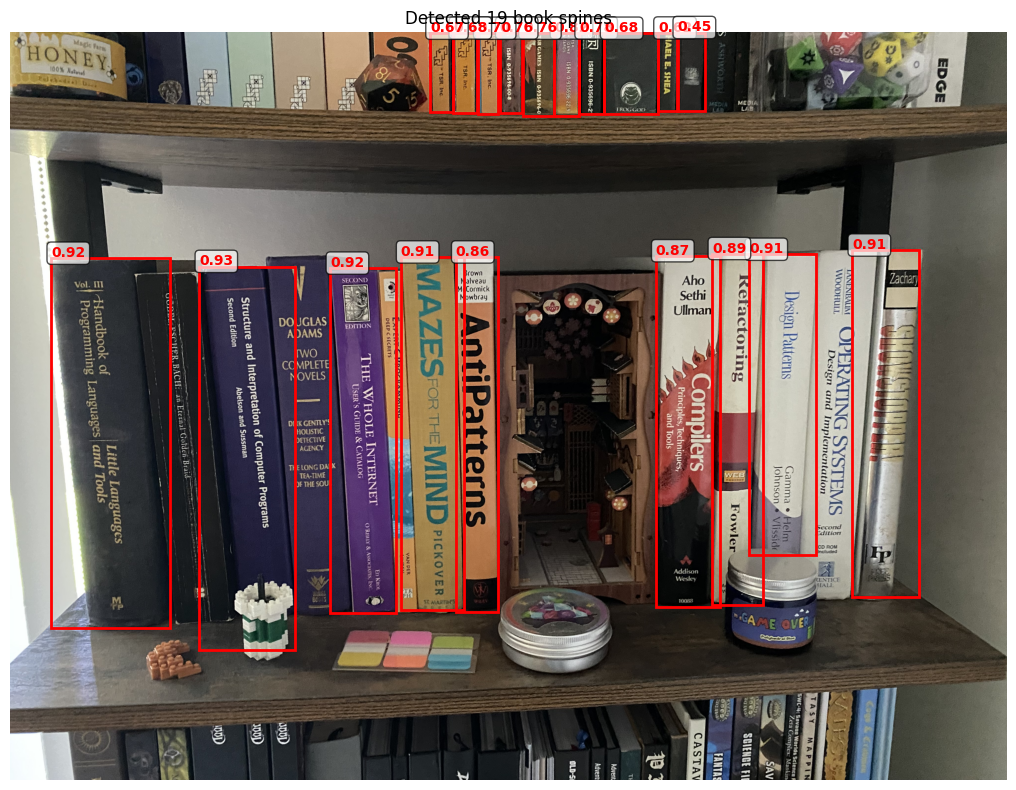


Found 19 book spines!
Book 1: confidence 93.43%
Book 2: confidence 92.47%
Book 3: confidence 92.44%
Book 4: confidence 90.83%
Book 5: confidence 90.77%
Book 6: confidence 90.62%
Book 7: confidence 88.69%
Book 8: confidence 87.48%
Book 9: confidence 86.22%
Book 10: confidence 81.90%
Book 11: confidence 77.84%
Book 12: confidence 76.07%
Book 13: confidence 75.86%
Book 14: confidence 70.38%
Book 15: confidence 68.10%
Book 16: confidence 67.59%
Book 17: confidence 66.59%
Book 18: confidence 61.82%
Book 19: confidence 44.78%


In [9]:
# Load the image
img = Image.open("IMG_4014.jpeg")

# Create figure and axes
fig, ax = plt.subplots(1, figsize=(12, 8))
ax.imshow(img)

# Draw bounding boxes for each detected book spine
for prediction in result['predictions']:
    x = prediction['x']
    y = prediction['y']
    width = prediction['width']
    height = prediction['height']
    confidence = prediction['confidence']
    
    # Calculate top-left corner from center coordinates
    x1 = x - width/2
    y1 = y - height/2
    
    # Create rectangle patch
    rect = patches.Rectangle(
        (x1, y1), width, height,
        linewidth=2, edgecolor='red', facecolor='none'
    )
    ax.add_patch(rect)
    
    # Add confidence label
    ax.text(x1, y1-5, f'{confidence:.2f}', 
            color='red', fontsize=10, weight='bold',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

plt.axis('off')
plt.title(f'Detected {len(result["predictions"])} book spines')
plt.tight_layout()
plt.show()

# Print summary
print(f"\nFound {len(result['predictions'])} book spines!")
for i, pred in enumerate(result['predictions'], 1):
    print(f"Book {i}: confidence {pred['confidence']:.2%}")